# Notebook 06 — Drake Passage Surface Transport

**Kinetic Energy Trends and Eddy Saturation in the Southern Ocean**

---

Computes a monthly **surface transport proxy** across Drake Passage by integrating CMEMS DUACS daily geostrophic velocities along an oblique transect (65°W 55°S → 60°W 63°S), and fits Theil–Sen / Modified Mann–Kendall trends.

**Inputs**

- CMEMS DUACS L4 daily geostrophic velocities (`cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D`), streamed or local
- `outputs/trends/wind_stress_trends.csv` etc. from Notebook 05 (for the eddy saturation synthesis)
- Observed transport CSVs from `scripts/extract_observed_drake_geostrophic_transport.py` (used in Notebook 07)

**Outputs** (to `outputs/trends/`, consumed by Notebook 07):

- `drake_passage_transport.csv` — monthly surface transport proxy (m² s⁻¹)
- `drake_passage_trends.csv` — trend summary


## 1. Setup and Imports

In [1]:
import os
import sys
import warnings
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy import feature as cfeature
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Disable flox-backed groupby reductions for Python 3.9 compatibility.
xr.set_options(use_flox=False)

# Show the active interpreter so package installs can be matched to the notebook kernel.
ACTIVE_PYTHON = sys.executable
EXPECTED_VENV = os.path.join(os.path.abspath(os.path.join(os.getcwd(), '..')), '.venv-1', 'bin', 'python')
print(f"Active Python      : {ACTIVE_PYTHON}")
print(f"Expected notebook  : {EXPECTED_VENV}")
if ACTIVE_PYTHON != EXPECTED_VENV:
    print("WARNING: this notebook is not using the repo's .venv-1 interpreter.")

# ── Copernicus Marine Toolbox ──────────────────────────────────────────────
try:
    import copernicusmarine
    _CMEMS_AVAILABLE = True
except ImportError:
    _CMEMS_AVAILABLE = False
    print("WARNING: copernicusmarine not installed — remote access unavailable.")
    print("         Install with:  pip install copernicusmarine")

if _CMEMS_AVAILABLE:
    print("Copernicus Marine Toolbox available: True")
    print("Run copernicusmarine.login() manually when remote access is needed.")
else:
    print("Copernicus Marine Toolbox available: False")

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

print(f"Repository root: {REPO_ROOT}")
print("Imports OK.")

Active Python      : .venv-1/bin/python
Expected notebook  : .venv-1/bin/python
Copernicus Marine Toolbox available: True
Run copernicusmarine.login() manually when remote access is needed.
Repository root: repository
Imports OK.


.venv-1/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

Altimetry dataset, transect endpoints, study period.

In [2]:
# ── Altimetry dataset (CMEMS DUACS L4 daily geostrophic velocities) ────────
ALTIMETRY_DATASET_ID = "cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D"

# Local data path — set to None to force remote streaming via copernicusmarine.
# Expected tree: LOCAL_DATA_DIR / {year} / {month:02d} / *.nc
LOCAL_DATA_DIR = "/Volumes/My Book/DUACS MY/all_sat/SEALEVEL_GLO_PHY_L4_MY_008_047/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_202411"

# ── Drake Passage section (oblique transect) ───────────────────────────────
# Endpoints: (65°W, 55°S) → (60°W, 63°S)
TRANSECT_LON_START  = -65.0
TRANSECT_LAT_START  = -55.0
TRANSECT_LON_END    = -60.0
TRANSECT_LAT_END    = -63.0
N_TRANSECT_POINTS   = 121
TRANSECT_BUFFER_DEG = 0.5

# ── Drake retrieval box (tight envelope around the transect) ───────────────
RETRIEVAL_LON_MIN = min(TRANSECT_LON_START, TRANSECT_LON_END) - TRANSECT_BUFFER_DEG
RETRIEVAL_LON_MAX = max(TRANSECT_LON_START, TRANSECT_LON_END) + TRANSECT_BUFFER_DEG
RETRIEVAL_LAT_MIN = min(TRANSECT_LAT_START, TRANSECT_LAT_END) - TRANSECT_BUFFER_DEG
RETRIEVAL_LAT_MAX = max(TRANSECT_LAT_START, TRANSECT_LAT_END) + TRANSECT_BUFFER_DEG

# ── Study period ───────────────────────────────────────────────────────────
YEAR_START = 2001
YEAR_END   = 2025
years      = np.arange(YEAR_START, YEAR_END + 1)

# ── Output ─────────────────────────────────────────────────────────────────
OUTPUT_DIR        = os.path.join(REPO_ROOT, 'outputs', 'trends')
SEA_ICE_MASK_PATH = os.path.join(REPO_ROOT, 'outputs', 'sea_ice_mask.nc')
os.makedirs(OUTPUT_DIR, exist_ok=True)

_local_available = (LOCAL_DATA_DIR is not None) and os.path.isdir(str(LOCAL_DATA_DIR))

print(f"Altimetry dataset : {ALTIMETRY_DATASET_ID}")
print(f"Local data dir    : {LOCAL_DATA_DIR!r}  ({'found' if _local_available else 'NOT found — will use remote'})")
print("Drake transect :")
print(f"  start = ({TRANSECT_LON_START:.1f}°, {TRANSECT_LAT_START:.1f}°)")
print(f"  end   = ({TRANSECT_LON_END:.1f}°, {TRANSECT_LAT_END:.1f}°)")
print(f"  samples = {N_TRANSECT_POINTS}")
print(f"Retrieval box  : lon=[{RETRIEVAL_LON_MIN}, {RETRIEVAL_LON_MAX}], lat=[{RETRIEVAL_LAT_MIN}, {RETRIEVAL_LAT_MAX}]")
print(f"Sea-ice mask   : {SEA_ICE_MASK_PATH}")
print(f"Period         : {YEAR_START}–{YEAR_END}")


Altimetry dataset : cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D
Local data dir    : '/Volumes/My Book/DUACS MY/all_sat/SEALEVEL_GLO_PHY_L4_MY_008_047/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_202411'  (NOT found — will use remote)
Drake transect :
  start = (-65.0°, -55.0°)
  end   = (-60.0°, -63.0°)
  samples = 121
Retrieval box  : lon=[-65.5, -59.5], lat=[-63.5, -54.5]
Sea-ice mask   : outputs/sea_ice_mask.nc
Period         : 2001–2025


## 3. Helper Functions

Theil–Sen, Modified Mann–Kendall, running mean, significance stars.

In [3]:
def theil_sen(x, y):
    """Theil-Sen robust slope.  Returns: slope, intercept, lo_slope, hi_slope."""
    mask = np.isfinite(y) & np.isfinite(x)
    if mask.sum() < 3:
        return np.nan, np.nan, np.nan, np.nan
    res = stats.theilslopes(np.asarray(y[mask], float), np.asarray(x[mask], float), alpha=0.95)
    return res.slope, res.intercept, res.low_slope, res.high_slope


def mann_kendall(y):
    """Non-parametric Mann-Kendall test.  Returns: tau, p_value."""
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(y)
    if mask.sum() < 4:
        return np.nan, np.nan
    ym = y[mask]
    n  = len(ym)
    s  = sum(np.sign(ym[j] - ym[k]) for k in range(n-1) for j in range(k+1, n))
    var_s = n * (n - 1) * (2 * n + 5) / 18.0
    z = (s - np.sign(s)) / np.sqrt(var_s) if s != 0 else 0.0
    p = 2 * stats.norm.sf(np.abs(z))
    tau = s / (n * (n - 1) / 2.0)
    return tau, p


def _mk_sigstars(p):
    if not np.isfinite(p):
        return ''
    return '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))


def running_mean(series, window=12):
    """Centred rolling mean; returns array of same length."""
    return pd.Series(series).rolling(window, center=True, min_periods=window // 2).mean().values


print("Helper functions defined (Theil–Sen + Mann–Kendall + running_mean).")


Helper functions defined (Theil–Sen + Mann–Kendall + running_mean).


## 4. Transect Geometry and Altimetry Loading

Build the oblique transect coordinates, then loop over all months loading daily geostrophic velocities (`ugos`, `vgos`) and projecting them onto the transect-normal direction.


In [4]:
import calendar as _calendar

# ── Build oblique transect coordinates ─────────────────────────────────────
transect_t    = np.linspace(0.0, 1.0, N_TRANSECT_POINTS)
transect_lons = TRANSECT_LON_START + transect_t * (TRANSECT_LON_END - TRANSECT_LON_START)
transect_lats = TRANSECT_LAT_START + transect_t * (TRANSECT_LAT_END - TRANSECT_LAT_START)
point_coord   = xr.DataArray(np.arange(N_TRANSECT_POINTS), dims='point', name='point')
lon_da        = xr.DataArray(transect_lons, dims='point', coords={'point': point_coord})
lat_da        = xr.DataArray(transect_lats, dims='point', coords={'point': point_coord})

# ── Geometric metrics ───────────────────────────────────────────────────────
R          = 6371e3
dlon       = np.deg2rad(np.diff(transect_lons))
dlat       = np.deg2rad(np.diff(transect_lats))
lat_mid    = np.deg2rad(0.5 * (transect_lats[:-1] + transect_lats[1:]))
dx_seg     = R * np.cos(lat_mid) * dlon
dy_seg     = R * dlat
seg_len    = np.sqrt(dx_seg**2 + dy_seg**2)

ds_point = np.empty(N_TRANSECT_POINTS, dtype=float)
ds_point[0]    = seg_len[0] / 2.0
ds_point[-1]   = seg_len[-1] / 2.0
ds_point[1:-1] = 0.5 * (seg_len[:-1] + seg_len[1:])

transect_coord_km  = np.concatenate(([0.0], np.cumsum(seg_len))) / 1e3
transect_length_km = float(seg_len.sum() / 1e3)

# ── Unit normal vector (left of path start → end) ──────────────────────────
lat_ref = np.deg2rad(0.5 * (TRANSECT_LAT_START + TRANSECT_LAT_END))
dx_tot  = R * np.cos(lat_ref) * np.deg2rad(TRANSECT_LON_END - TRANSECT_LON_START)
dy_tot  = R * np.deg2rad(TRANSECT_LAT_END - TRANSECT_LAT_START)
t_norm  = np.hypot(dx_tot, dy_tot)
tx, ty  = dx_tot / t_norm, dy_tot / t_norm
nx, ny  = -ty, tx

# ── Sea-ice mask along the transect ────────────────────────────────────────
ice_mask_transect = None
if os.path.exists(SEA_ICE_MASK_PATH):
    with xr.open_dataset(SEA_ICE_MASK_PATH) as ds_ice:
        if 'ice_mask' in ds_ice:
            ice_mask_transect = (
                ds_ice['ice_mask'].interp(longitude=lon_da, latitude=lat_da).fillna(0).values > 0.5
            )
            print(f"Sea-ice mask: {ice_mask_transect.sum()} of {N_TRANSECT_POINTS} transect points masked")
        else:
            print("WARNING: 'ice_mask' not found in sea_ice_mask.nc")
else:
    print(f"WARNING: sea-ice mask not found at {SEA_ICE_MASK_PATH}")

print(f"Transect: {N_TRANSECT_POINTS} points, length ≈ {transect_length_km:.1f} km")
print(f"Normal vector: nx={nx:+.4f}, ny={ny:+.4f}")


# ── Helper: load one month from LOCAL files ────────────────────────────────
def _load_month_local(year, month, local_dir):
    """Average daily ugos/vgos over one month from local netCDF files."""
    mo_str  = f"{month:02d}"
    mo_path = os.path.join(local_dir, str(year), mo_str)
    if not os.path.isdir(mo_path):
        return None, None
    files = sorted([os.path.join(mo_path, f) for f in os.listdir(mo_path) if f.endswith('.nc')])
    if not files:
        return None, None
    try:
        ds  = xr.open_mfdataset(files, combine='by_coords')[['ugos', 'vgos']]
        ds  = ds.sel(longitude=slice(RETRIEVAL_LON_MIN, RETRIEVAL_LON_MAX),
                     latitude=slice(RETRIEVAL_LAT_MIN,  RETRIEVAL_LAT_MAX))
        u_m = ds['ugos'].mean(dim='time').interp(longitude=lon_da, latitude=lat_da).values.astype(float)
        v_m = ds['vgos'].mean(dim='time').interp(longitude=lon_da, latitude=lat_da).values.astype(float)
        ds.close()
        return u_m, v_m
    except Exception as e:
        print(f"  local load failed ({year}/{mo_str}): {e}")
        return None, None


# ── Helper: stream one month from CMEMS ───────────────────────────────────
def _load_month_remote(year, month):
    """Stream monthly mean ugos/vgos from CMEMS for one month."""
    mo_str   = f"{month:02d}"
    last_day = _calendar.monthrange(year, month)[1]
    start    = f"{year}-{mo_str}-01"
    end      = f"{year}-{mo_str}-{last_day:02d}"
    try:
        ds  = copernicusmarine.open_dataset(
            dataset_id        = ALTIMETRY_DATASET_ID,
            minimum_longitude = RETRIEVAL_LON_MIN,
            maximum_longitude = RETRIEVAL_LON_MAX,
            minimum_latitude  = RETRIEVAL_LAT_MIN,
            maximum_latitude  = RETRIEVAL_LAT_MAX,
            start_datetime    = start,
            end_datetime      = end,
            variables         = ["ugos", "vgos"],
        )
        u_m = ds['ugos'].mean(dim='time').interp(longitude=lon_da, latitude=lat_da).values.astype(float)
        v_m = ds['vgos'].mean(dim='time').interp(longitude=lon_da, latitude=lat_da).values.astype(float)
        ds.close()
        return u_m, v_m
    except Exception as e:
        print(f"  remote load failed ({year}/{mo_str}): {e}")
        return None, None


Sea-ice mask: 69 of 121 transect points masked
Transect: 121 points, length ≈ 934.6 km
Normal vector: nx=+0.9519, ny=+0.3064


In [5]:
# ── Main loop: load monthly altimetry and project onto transect ────────────
print(f"Processing {YEAR_START}–{YEAR_END} ({(YEAR_END - YEAR_START + 1) * 12} months)...")

times_list    = []
vn_trans_list = []   # normal velocity along transect [m/s], shape per entry: (N_TRANSECT_POINTS,)

for year in range(YEAR_START, YEAR_END + 1):
    for month in range(1, 13):
        print(f"  {year}-{month:02d}", end='', flush=True)

        u_m, v_m = None, None
        if _local_available:
            u_m, v_m = _load_month_local(year, month, LOCAL_DATA_DIR)
        if u_m is None and _CMEMS_AVAILABLE:
            u_m, v_m = _load_month_remote(year, month)

        times_list.append(pd.Timestamp(year=year, month=month, day=1))

        if u_m is None:
            print(" [MISSING]", end='')
            vn_trans_list.append(np.full(N_TRANSECT_POINTS, np.nan))
        else:
            # Apply sea-ice mask
            if ice_mask_transect is not None:
                u_m[ice_mask_transect] = np.nan
                v_m[ice_mask_transect] = np.nan
            # Perpendicular (normal) velocity component
            vn_trans_list.append(u_m * nx + v_m * ny)
        print()

times_drake  = pd.DatetimeIndex(times_list)
vn_transect  = np.array(vn_trans_list)   # (n_months, N_TRANSECT_POINTS)
lats_drake   = transect_lats

n_ok = int(np.isfinite(vn_transect[:, N_TRANSECT_POINTS // 2]).sum())
print(f"\nLoaded: {len(times_drake)} months total, {n_ok} with valid data")
print(f"Normal velocity array: {vn_transect.shape}  (n_months × n_transect_points)")
print(f"Period: {times_drake[0].strftime('%Y-%m')} to {times_drake[-1].strftime('%Y-%m')}")


Processing 2001–2025 (300 months)...
  2001-01

INFO - 2026-07-06T09:01:18Z - Selected dataset version: "202411"
INFO - 2026-07-06T09:01:18Z - Selected dataset part: "default"



  2001-02

INFO - 2026-07-06T09:01:29Z - Selected dataset version: "202411"
INFO - 2026-07-06T09:01:29Z - Selected dataset part: "default"



  2001-03

...


  2025-11

INFO - 2026-07-06T10:02:17Z - Selected dataset version: "202411"
INFO - 2026-07-06T10:02:17Z - Selected dataset part: "default"



  2025-12

INFO - 2026-07-06T10:02:34Z - Selected dataset version: "202411"
INFO - 2026-07-06T10:02:34Z - Selected dataset part: "default"




Loaded: 300 months total, 0 with valid data
Normal velocity array: (300, 121)  (n_months × n_transect_points)
Period: 2001-01 to 2025-12


## 5. Surface Transport Proxy

Integrate the geostrophic normal velocity along the transect:

$$T_{surf}(t) = \int v_n(s, t)\, ds \quad [\mathrm{m^2\,s^{-1}}]$$

a surface proxy for the full-depth transport (compared against in-situ observations in Notebook 07).


In [6]:
# ── Integrate normal velocity along transect ──────────────────────────────
n_months      = len(times_drake)
transport_m2s = np.full(n_months, np.nan)

for t in range(n_months):
    vn      = vn_transect[t]                               # (N_TRANSECT_POINTS,)
    v_clean = np.where(np.isfinite(vn), vn, 0.0)
    transport_m2s[t] = np.sum(v_clean * ds_point)         # m/s * m = m²/s

print(f"Along-transect spacing : {ds_point.min()/1e3:.2f}–{ds_point.max()/1e3:.2f} km")
print(f"Transect length        : {ds_point.sum()/1e3:.2f} km")
print(f"\nSurface transport proxy (T_surf):")
print(f"  Mean   : {np.nanmean(transport_m2s):.2f} m² s⁻¹")
print(f"  Std    : {np.nanstd(transport_m2s):.2f} m² s⁻¹")
print(f"  Min/Max: {np.nanmin(transport_m2s):.2f} / {np.nanmax(transport_m2s):.2f} m² s⁻¹")


Along-transect spacing : 3.85–7.87 km
Transect length        : 934.62 km

Surface transport proxy (T_surf):
  Mean   : 78402.96 m² s⁻¹
  Std    : 11465.98 m² s⁻¹
  Min/Max: 42136.61 / 110068.12 m² s⁻¹


## 6. Monthly Time Series and Trend

Build the monthly DataFrame, fit the annual-mean Theil–Sen trend with MK significance, and plot the series.

Drake Passage surface transport  (2001–2025):
  Mean            : 78402.96 m² s⁻¹
  Theil–Sen slope : +2008.9192 m² s⁻¹/10yr  [-824.6882, +4506.3176]
  Mann–Kendall    : tau = +0.200, p = 0.1682 


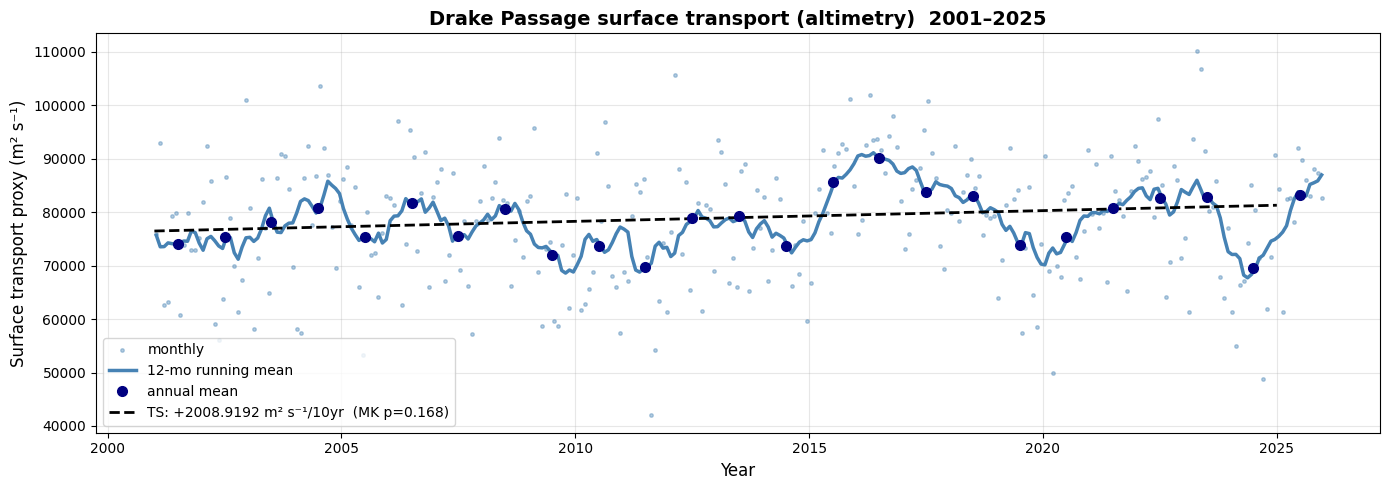

In [8]:
# ── Build DataFrame ─────────────────────────────────────────────────────────
df_transport = pd.DataFrame({
    'time'          : times_drake,
    'year'          : times_drake.year,
    'month'         : times_drake.month,
    'transport_m2s' : transport_m2s,
})

df_annual = df_transport.groupby('year')['transport_m2s'].mean().reset_index()

# ── Trend statistics (annual means) ─────────────────────────────────────────
x_yr   = df_annual['year'].values.astype(float)
y_m2s  = df_annual['transport_m2s'].values.astype(float)

ts_sl, ts_int, ts_lo, ts_hi = theil_sen(x_yr, y_m2s)
mk_tau, mk_p                = mann_kendall(y_m2s)
sig_mk                      = _mk_sigstars(mk_p)

print(f"Drake Passage surface transport  ({YEAR_START}–{YEAR_END}):")
print(f"  Mean            : {np.nanmean(y_m2s):.2f} m² s⁻¹")
print(f"  Theil–Sen slope : {ts_sl*10:+.4f} m² s⁻¹/10yr  [{ts_lo*10:+.4f}, {ts_hi*10:+.4f}]")
print(f"  Mann–Kendall    : tau = {mk_tau:+.3f}, p = {mk_p:.4f} {sig_mk}")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

t_frac = df_transport['year'] + (df_transport['month'] - 0.5) / 12.0

ax.plot(t_frac, transport_m2s, '.', color='steelblue', ms=5, alpha=0.4, label='monthly')
ax.plot(t_frac, running_mean(transport_m2s), '-', color='steelblue', lw=2.5,
        label='12-mo running mean')
ax.plot(df_annual['year'] + 0.5, y_m2s, 'o', color='navy', ms=7, zorder=5,
        label='annual mean')
trend_line = ts_sl * x_yr + ts_int
ax.plot(x_yr, trend_line, 'k--', lw=2,
        label=(f"TS: {ts_sl*10:+.4f} m² s⁻¹/10yr  (MK p={mk_p:.3f}{sig_mk})"))

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Surface transport proxy (m² s⁻¹)', fontsize=12)
ax.set_title(f'Drake Passage surface transport (altimetry)  {YEAR_START}–{YEAR_END}',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Eddy Saturation Synthesis

Combine the wind stress trends (Notebook 05), KE/EKE trends and the transport trend: under eddy saturation, strengthening winds increase EKE while mean flow and transport remain approximately constant.


In [14]:
# ── Eddy saturation synthesis ─────────────────────────────────────────────
wind_path = os.path.join(REPO_ROOT, 'outputs', 'trends', 'wind_stress_trends.csv')
if not os.path.exists(wind_path):
    raise FileNotFoundError(f"Missing wind stress trends CSV: {wind_path}\nRun Notebook 05 first.")

df_wind_tr = pd.read_csv(wind_path)

def _pick_trend(df, sector, variable):
    sub = df[(df['sector'] == sector) & (df['variable'] == variable)].copy()
    if sub.empty:
        raise ValueError(f"No rows for sector={sector!r}, variable={variable!r}")
    return sub.iloc[0]

wind_whole = _pick_trend(df_wind_tr, 'Whole ACC', 'tau_x')

# Altimetry surface transport trend
df_ann_tr = df_transport.groupby('year', as_index=False)['transport_m2s'].mean().dropna()
x = df_ann_tr['year'].values.astype(float)
y = df_ann_tr['transport_m2s'].values.astype(float)
tr_slope, tr_int, tr_lo, tr_hi = theil_sen(x, y)
tr_tau, tr_p = mann_kendall(y)

saturation = pd.DataFrame([{
    'wind_variable'              : 'tau_x',
    'wind_sector'                : 'Whole ACC',
    'wind_ts_slope_per_10yr'     : wind_whole['theil_sen_slope_per_year'] * 10.0,
    'wind_mk_p'                  : wind_whole['mann_kendall_p'],
    'transport_source'           : 'altimetry_surface_proxy',
    'transport_units'            : 'm2_per_s',
    'transport_ts_slope_per_10yr': tr_slope * 10.0,
    'transport_mk_p'             : tr_p,
    'wind_significant_05'        : bool(wind_whole.get('significant_05', False)),
    'transport_significant_05'   : bool(np.isfinite(tr_p) and (tr_p < 0.05)),
}])

display(saturation)


KeyError: 'theil_sen_slope_per_year'

## 8. Save Results

Write `drake_passage_transport.csv` (monthly series) and `drake_passage_trends.csv` (trend summary) to `outputs/trends/`.

In [ ]:
out_dir  = os.path.join(REPO_ROOT, 'outputs', 'trends')
os.makedirs(out_dir, exist_ok=True)
out_ts   = os.path.join(out_dir, 'drake_passage_transport.csv')
out_trnd = os.path.join(out_dir, 'drake_passage_trends.csv')

# ── Monthly time series ────────────────────────────────────────────────────
df_save = df_transport.copy()
df_save['decimal_year'] = df_save['year'] + (df_save['month'] - 0.5) / 12.0
df_save.to_csv(out_ts, index=False)
print(f"Saved: {out_ts}")
print(f"  Columns: {df_save.columns.tolist()}")
print(f"  Rows   : {len(df_save)}")

# ── Trend summary ─────────────────────────────────────────────────────────
df_ann_s = df_save.groupby('year')['transport_m2s'].mean().reset_index()
x = df_ann_s['year'].values.astype(float)
y = df_ann_s['transport_m2s'].values.astype(float)

slope, intercept, lo, hi = theil_sen(x, y)
mk_tau, mk_p             = mann_kendall(y)

df_out = pd.DataFrame([{
    'series'                      : 'drake_passage_altimetry_surface_transport',
    'units'                       : 'm2_per_s',
    'theil_sen_slope_per_year'    : slope,
    'theil_sen_ci95_low_per_year' : lo,
    'theil_sen_ci95_high_per_year': hi,
    'mann_kendall_tau'            : mk_tau,
    'mann_kendall_p'              : mk_p,
    'significant_05'              : bool(np.isfinite(mk_p) and (mk_p < 0.05)),
}])

df_out.to_csv(out_trnd, index=False)
print(f"Saved: {out_trnd}")
display(df_out)


Saved: outputs/trends/drake_passage_transport.csv
  Columns: ['time', 'year', 'month', 'transport_m2s', 'anom', 'decimal_year']
  Rows   : 288
Saved: outputs/trends/drake_passage_trends.csv


,series,units,theil_sen_slope_per_year,theil_sen_ci95_low_per_year,theil_sen_ci95_high_per_year,mann_kendall_tau,mann_kendall_p,significant_05
0,drake_passage_altimetry_surface_transport,m2_per_s,168.086226,-184.254985,478.512143,0.152174,0.309163,False


## Summary

Altimetry-derived Drake Passage surface transport proxy with non-parametric trend statistics, feeding the combined publication figure in Notebook 07.
